In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy.optimize
import random

np.random.seed(123)

In [85]:
eps = np.random.normal(0,1, 20)
b, k = 2.0, 2.0
x = np.arange(-1.8, 2.2, 0.2)
y = k*x + b + eps


In [86]:
'''
y = kx+b
least squares method
'''
def LSM(x : np.ndarray, y: np.ndarray) -> float:
    '''
    return k, b
    '''
    
    k, b = 0, 0
    nominator = 0
    denominator = 0

    xm = np.mean(x)
    ym = np.mean(y)
    for i in range(len(x)):
        nominator += (x[i]-xm)*(y[i]- ym)
        denominator += (x[i] - xm)**2
    k = nominator/denominator
    b = ym - k*xm

    # print(k, b)
    return k, b

In [87]:
from scipy.optimize import minimize
def target(params, x : np.ndarray, y : np.ndarray) -> float:
    '''
    return absolute error
    '''
    k, b = params
    err = 0

    for i in range(len(x)):
        err += np.fabs(y[i] - ( b + k*x[i]))
    
    return err

def minim_module(x: np.ndarray, y :np.ndarray) -> float:
    '''
    minimize abolute error and return k, b
    '''
    begin = [0., 0.]
    res = minimize(target, begin, args=(x,y))
    
    kk = res.x[0]
    bb = res.x[1]

    return kk,bb

In [ ]:
for i in range(len(x)):
    print(x[i], y[i])

In [89]:
para = [k,b]
target(para,x,y)
kk, bb = minim_module(x,y)
print(f'mmm:\n k: {kk}, b: {bb}')

a,b = LSM(x,y)
print(f'lsm:\n a: {a}, b: {b}')

mmm:
 k: 2.337333985249982, b: 1.7587337345163305
lsm:
 a: 2.3979114502931735, b: 2.0746265869259735


# построение графиков

(Text(0.5, 0, 'x'), Text(0, 0.5, 'y'))

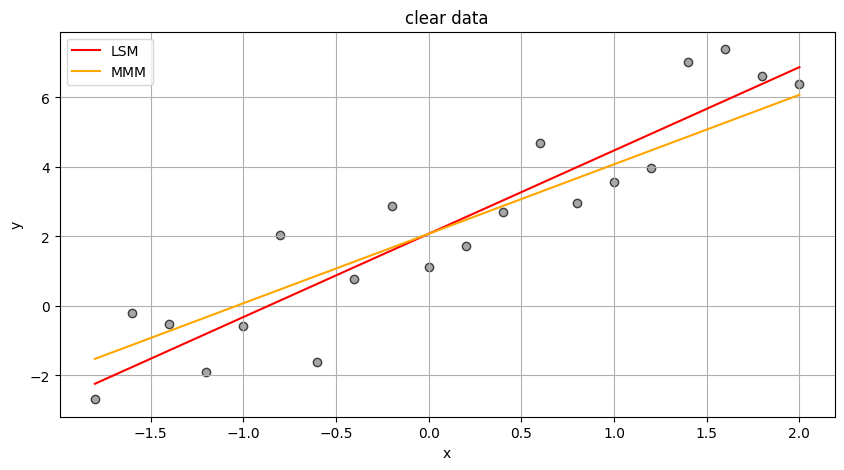

In [99]:
y_lsm = a*x+b
y_mmm = k*x+b

plt.figure(figsize=(10,5))
plt.grid()
plt.plot(x, y_lsm, color = 'red', label= 'LSM')
plt.plot(x, y_mmm, color ='orange', label = 'MMM')
plt.scatter(x,y, color='grey', edgecolor='black', alpha =0.7)
plt.legend()
plt.title('clear data')
plt.xlabel('x'), plt.ylabel('y')

# данные с выбросами

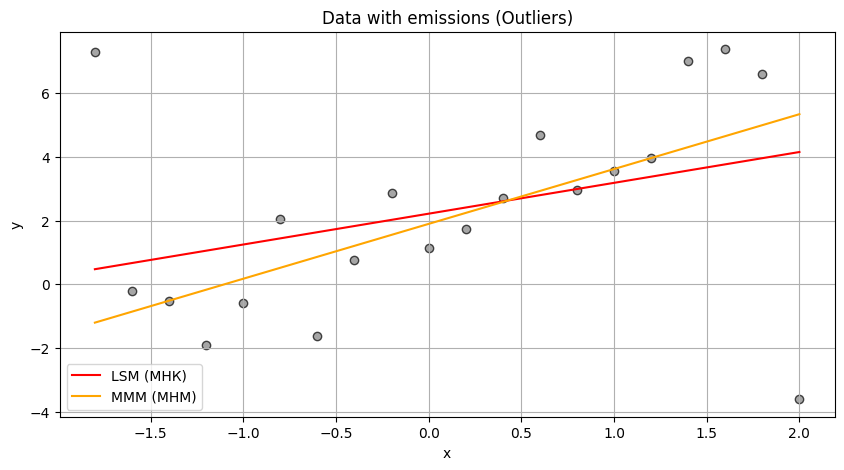

In [98]:
x = np.arange(-1.8, 2.2, 0.2)
y2 = y.copy() 
y2[0] += 10   
y2[19] -= 10

k2tmp, b2tmp = minim_module(x, y2)
k2lsm, b2lsm = LSM(x, y2)

y2_lsm = k2lsm * x + b2lsm
y2_mmm = k2tmp * x + b2tmp 

plt.figure(figsize=(10,5))
plt.grid()
plt.plot(x, y2_lsm, color='red', label='LSM (МНК)')
plt.plot(x, y2_mmm, color='orange', label='MMM (МНМ)')
plt.scatter(x, y2, color='grey', edgecolor='black', alpha=0.7)
plt.legend()
plt.title('Data with emissions (Outliers)')
plt.xlabel('x'), plt.ylabel('y')
plt.show()


In [97]:
true_a, true_b = 2.0, 2.0
y_outliers = y.copy()
y_outliers[0] += 10
y_outliers[-1] -= 10


def MMM(x: np.ndarray, y :np.ndarray) -> float:
    '''
    minimize abolute error and return k, b
    '''
    begin = [0., 0.]
    res = minimize(target, begin, args=(x,y))

    return res.x

def get_results_table(x, y, label):
    # Считаем коэффициенты
    a_lsm, b_lsm = LSM(x, y)
    a_mmm, b_mmm = MMM(x, y)
    
    methods = ['МНК', 'МНМ']
    coeffs_a = [a_lsm, a_mmm]
    coeffs_b = [b_lsm, b_mmm]
    
    data = []
    for i in range(2):
        a_est, b_est = coeffs_a[i], coeffs_b[i]
        
        # Абсолютные погрешности
        delta_a = abs(true_a - a_est)
        delta_b = abs(true_b - b_est)
        
        # Относительные погрешности (%)
        rel_a = (delta_a / true_a) * 100
        rel_b = (delta_b / true_b) * 100
        
        data.append([methods[i], round(a_est, 4), round(delta_a, 4), round(rel_a, 2),
                     round(b_est, 4), round(delta_b, 4), round(rel_b, 2)])
    
    cols = ['Метод', 'a', 'Δ a', 'δ a, %', 'b', 'Δ b', 'δ b, %']
    df = pd.DataFrame(data, columns=cols)
    print(f"\nРезультаты ({label}):")
    print(df.to_string(index=False))
    return df, (a_lsm, b_lsm), (a_mmm, b_mmm)


# 1. Без выбросов
df1, lsm_norm, mmm_norm = get_results_table(x, y, "Чистые данные")

# 2. С выбросами
df2, lsm_out, mmm_out = get_results_table(x, y_outliers, "С выбросами")



Результаты (Чистые данные):
Метод      a    Δ a  δ a, %      b    Δ b  δ b, %
  МНК 2.3979 0.3979   19.90 2.0746 0.0746    3.73
  МНМ 2.3373 0.3373   16.87 1.7587 0.2413   12.06

Результаты (С выбросами):
Метод      a    Δ a  δ a, %      b    Δ b  δ b, %
  МНК 0.9693 1.0307   51.53 2.2175 0.2175   10.87
  МНМ 1.7241 0.2759   13.79 1.8967 0.1033    5.16
